In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb
import pandas as pd
from sklearn.linear_model import LinearRegression


In [10]:
train = pd.read_csv("train_cleaned.csv")
test = pd.read_csv("test_cleaned.csv")

In [11]:
train.head()

,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Father's name,Mother's age,Father's age,...,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder
0,2.0,Yes,No,Yes,No,4.760603,Richard,Larre,35.0,42.0,...,2.0,Singular,9.857562,slightly abnormal,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders
1,4.0,Yes,Yes,No,No,4.910669,Mike,Brycen,35.0,23.0,...,2.0,Multiple,5.522560,normal,1.0,1.0,1.0,1.0,0.0,Mitochondrial genetic inheritance disorders
2,6.0,Yes,No,No,No,4.893297,Kimberly,Nashon,41.0,22.0,...,4.0,Singular,7.477132,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders
3,12.0,Yes,No,Yes,No,4.705280,Jeffery,Aayaan,21.0,42.0,...,1.0,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders
4,11.0,Yes,No,Yes,Yes,4.720703,Johanna,Suave,32.0,42.0,...,4.0,Multiple,4.098210,slightly abnormal,0.0,0.0,0.0,0.0,0.0,Multifactorial genetic inheritance disorders


In [12]:
train.shape

(22083, 41)

In [13]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 22083 entries, 0 to 22082
Data columns (total 41 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Age                                       22083 non-null  float64
 1   Genes in mother's side                            22083 non-null  str    
 2   Inherited from father                             22083 non-null  str    
 3   Maternal gene                                     22083 non-null  str    
 4   Paternal gene                                     22083 non-null  str    
 5   Blood cell count (mcL)                            22083 non-null  float64
 6   Patient First Name                                22083 non-null  str    
 7   Father's name                                     22083 non-null  str    
 8   Mother's age                                      22083 non-null  float64
 9   Father's age                

In [14]:
train.describe()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,22083.000000,22083.000000,22083.000000,22083.000000,22083.0,22083.0,22083.0,22083.0,22083.0,22083.000000,22083.000000,22083.000000,22083.000000,22083.000000,22083.000000,22083.000000
mean,6.975819,4.898871,34.655889,41.980211,0.0,0.0,0.0,1.0,0.0,2.002762,7.485340,0.632251,0.596975,0.580356,0.450120,0.416882
std,4.177581,0.199663,8.401407,11.129297,0.0,0.0,0.0,0.0,0.0,1.341020,2.521040,0.482203,0.490517,0.493512,0.497517,0.493054
min,0.000000,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.763109,29.000000,35.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.653911,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899399,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.477132,1.000000,1.000000,1.000000,0.000000,0.000000
75%,10.000000,5.033830,40.000000,49.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.279380,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
train.isnull().sum()

Patient Age                                         0
Genes in mother's side                              0
Inherited from father                               0
Maternal gene                                       0
Paternal gene                                       0
Blood cell count (mcL)                              0
Patient First Name                                  0
Father's name                                       0
Mother's age                                        0
Father's age                                        0
Location of Institute                               0
Status                                              0
Respiratory Rate (breaths/min)                      0
Heart Rate (rates/min                               0
Test 1                                              0
Test 2                                              0
Test 3                                              0
Test 4                                              0
Test 5                      

In [16]:
train["Genetic Disorder"].value_counts()

Genetic Disorder
Mitochondrial genetic inheritance disorders     12348
Single-gene inheritance diseases                 7664
Multifactorial genetic inheritance disorders     2071
Name: count, dtype: int64

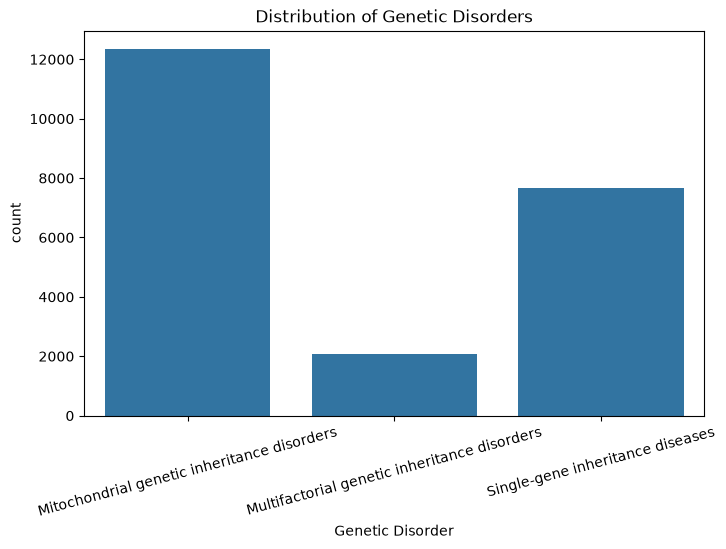

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x="Genetic Disorder", data=train)
plt.title("Distribution of Genetic Disorders")
plt.xticks(rotation=15)
plt.show()

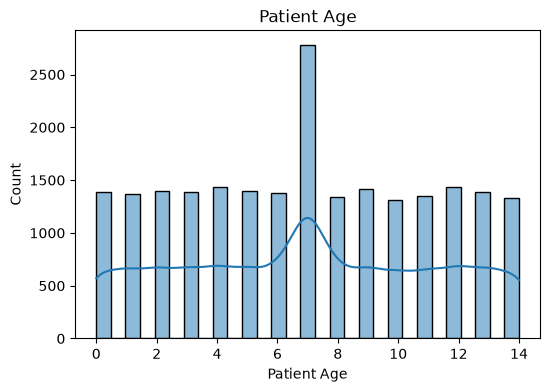

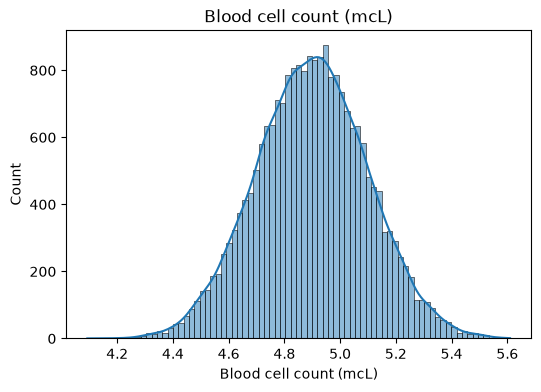

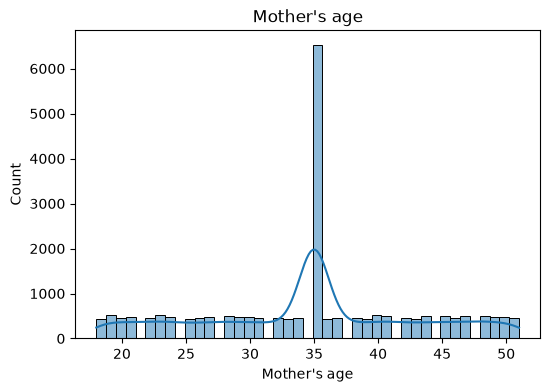

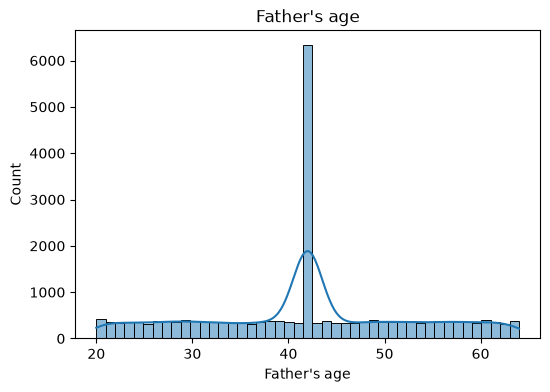

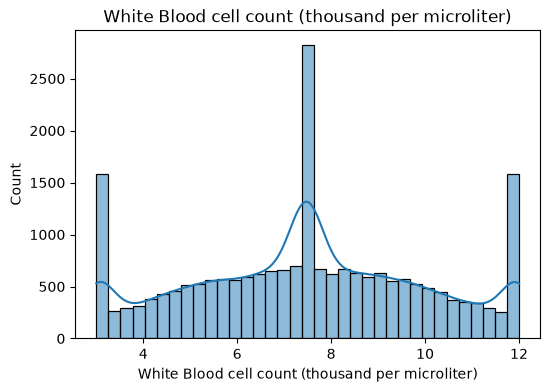

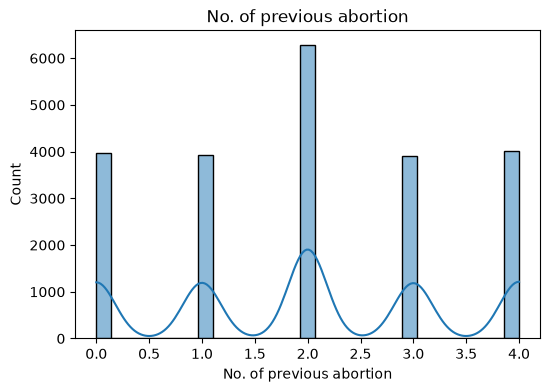

In [29]:
num_cols = [
    "Patient Age",
    "Blood cell count (mcL)",
    "Mother's age",
    "Father's age",
    "White Blood cell count (thousand per microliter)",
    "No. of previous abortion"
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(train[col], kde=True)
    plt.title(col)
    plt.show()

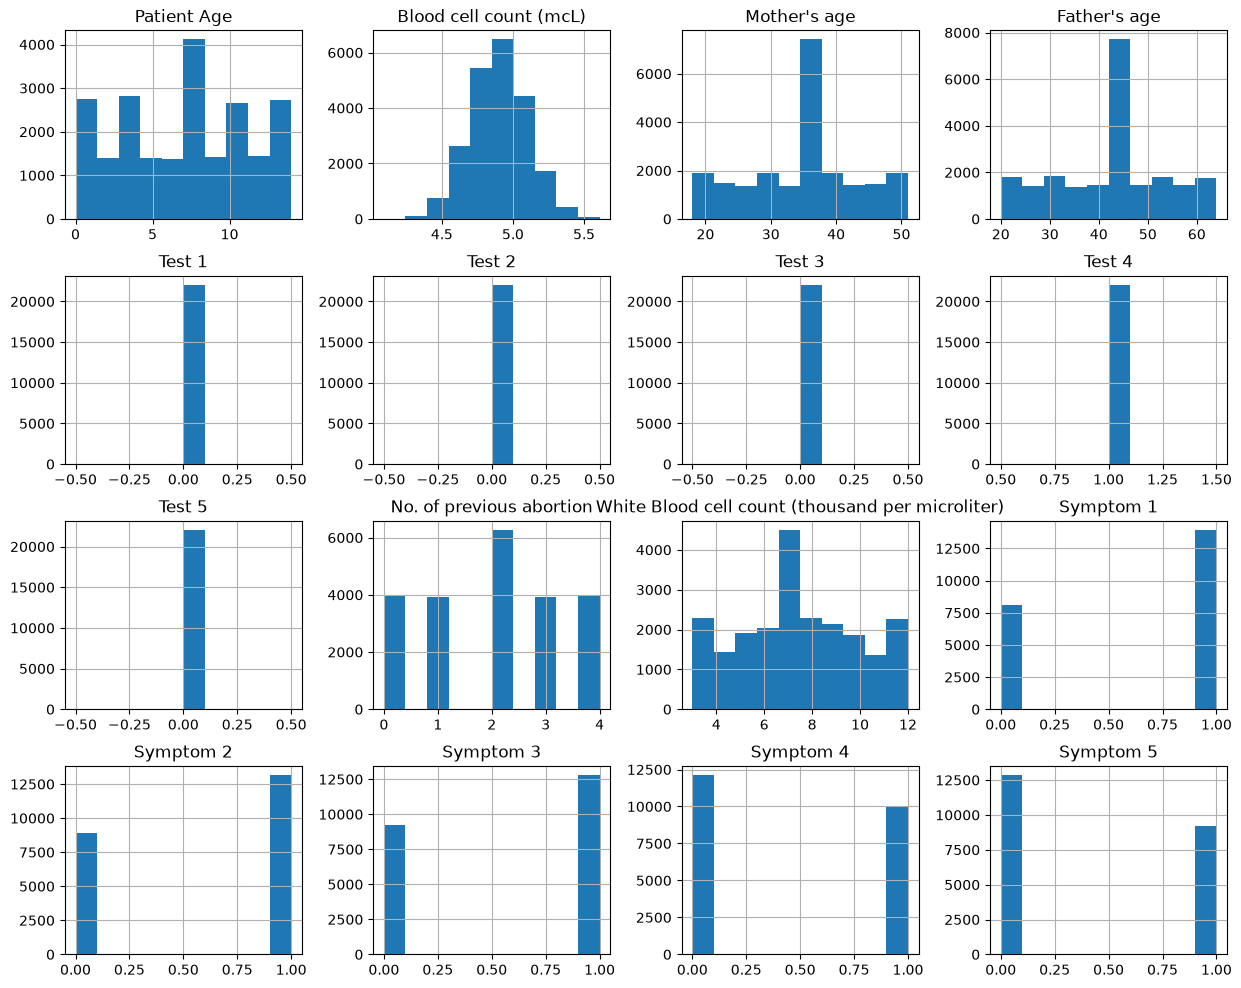

In [18]:
train.hist(figsize=(15,12))
plt.show()

In [21]:
train.columns

Index(['Patient Age', 'Genes in mother's side', 'Inherited from father',
       'Maternal gene', 'Paternal gene', 'Blood cell count (mcL)',
       'Patient First Name', 'Father's name', 'Mother's age', 'Father's age',
       'Location of Institute', 'Status', 'Respiratory Rate (breaths/min)',
       'Heart Rate (rates/min', 'Test 1', 'Test 2', 'Test 3', 'Test 4',
       'Test 5', 'Parental consent', 'Follow-up', 'Gender', 'Birth asphyxia',
       'Autopsy shows birth defect (if applicable)', 'Place of birth',
       'Folic acid details (peri-conceptional)',
       'H/O serious maternal illness', 'H/O radiation exposure (x-ray)',
       'H/O substance abuse', 'Assisted conception IVF/ART',
       'History of anomalies in previous pregnancies',
       'No. of previous abortion', 'Birth defects',
       'White Blood cell count (thousand per microliter)', 'Blood test result',
       'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5',
       'Genetic Disorder'],
      dtype='st

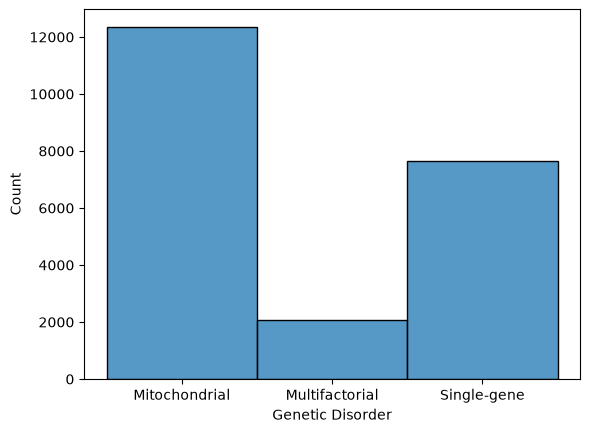

In [26]:
temp = train.copy()

temp["Genetic Disorder"] = temp["Genetic Disorder"].replace({
    "Mitochondrial genetic inheritance disorders": "Mitochondrial",
    "Multifactorial genetic inheritance disorders": "Multifactorial",
    "Single-gene inheritance diseases": "Single-gene"
})

sns.histplot(data=temp, x="Genetic Disorder")
plt.show()

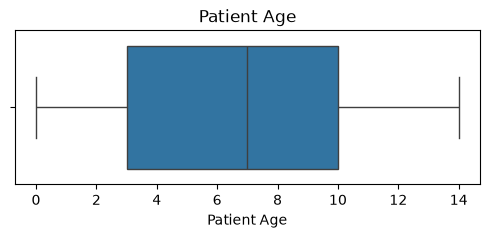

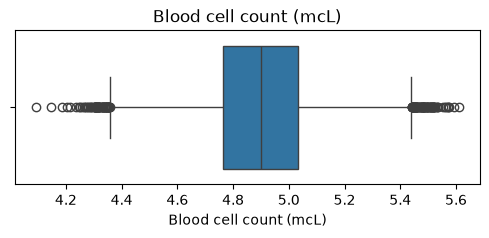

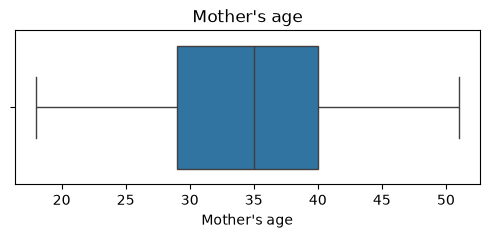

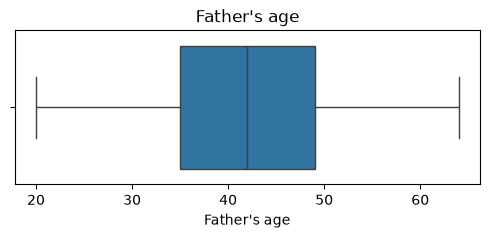

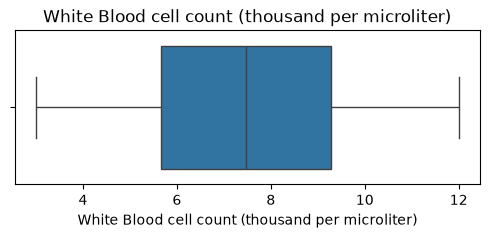

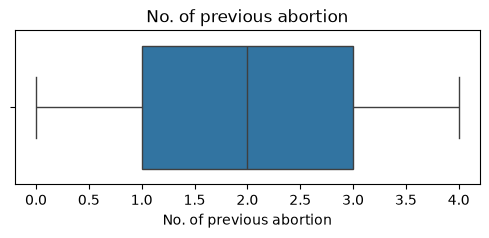

In [30]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

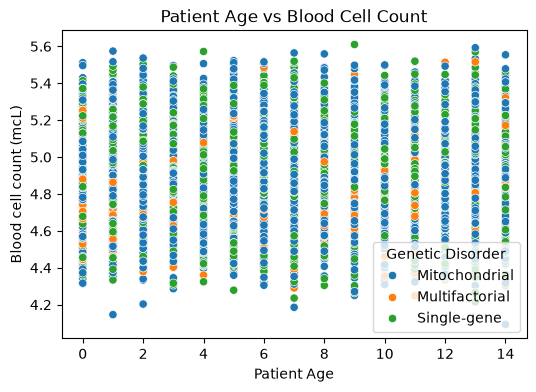

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=train,
                x="Patient Age",
                y="Blood cell count (mcL)",
                hue="Genetic Disorder")

plt.title("Patient Age vs Blood Cell Count")
plt.show()

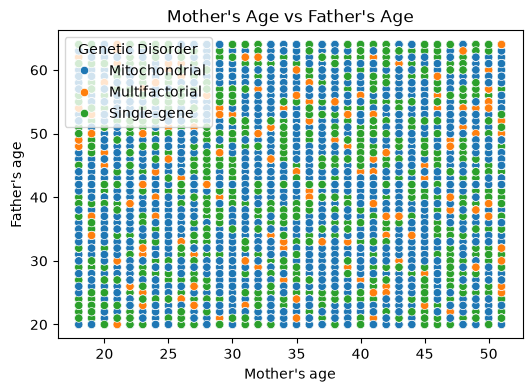

In [33]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=train,
                x="Mother's age",
                y="Father's age",
                hue="Genetic Disorder")

plt.title("Mother's Age vs Father's Age")
plt.show()

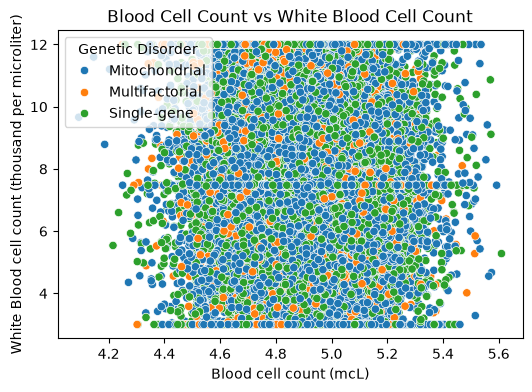

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=train,
                x="Blood cell count (mcL)",
                y="White Blood cell count (thousand per microliter)",
                hue="Genetic Disorder")

plt.title("Blood Cell Count vs White Blood Cell Count")
plt.show()

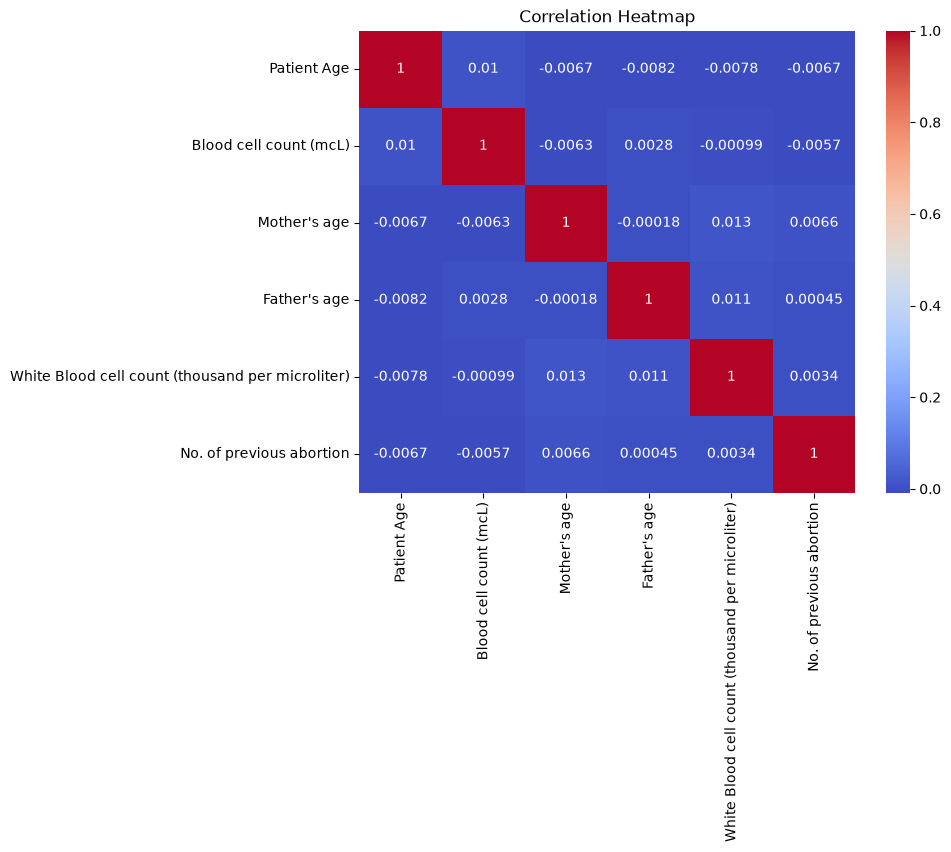

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

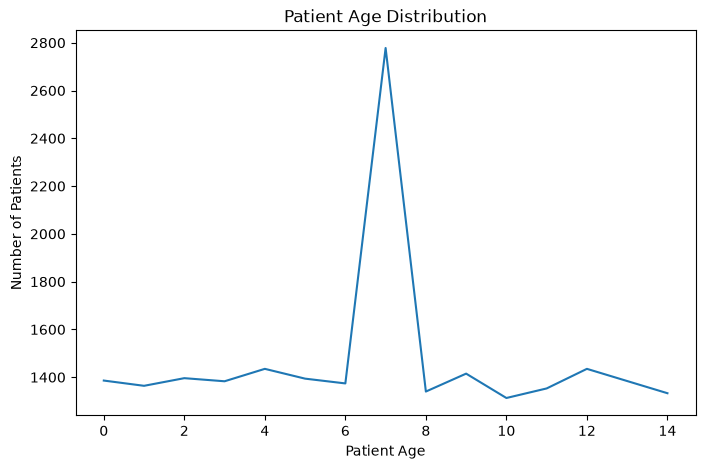

In [37]:
age_count = train["Patient Age"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(age_count.index, age_count.values)

plt.title("Patient Age Distribution")
plt.xlabel("Patient Age")
plt.ylabel("Number of Patients")
plt.show()

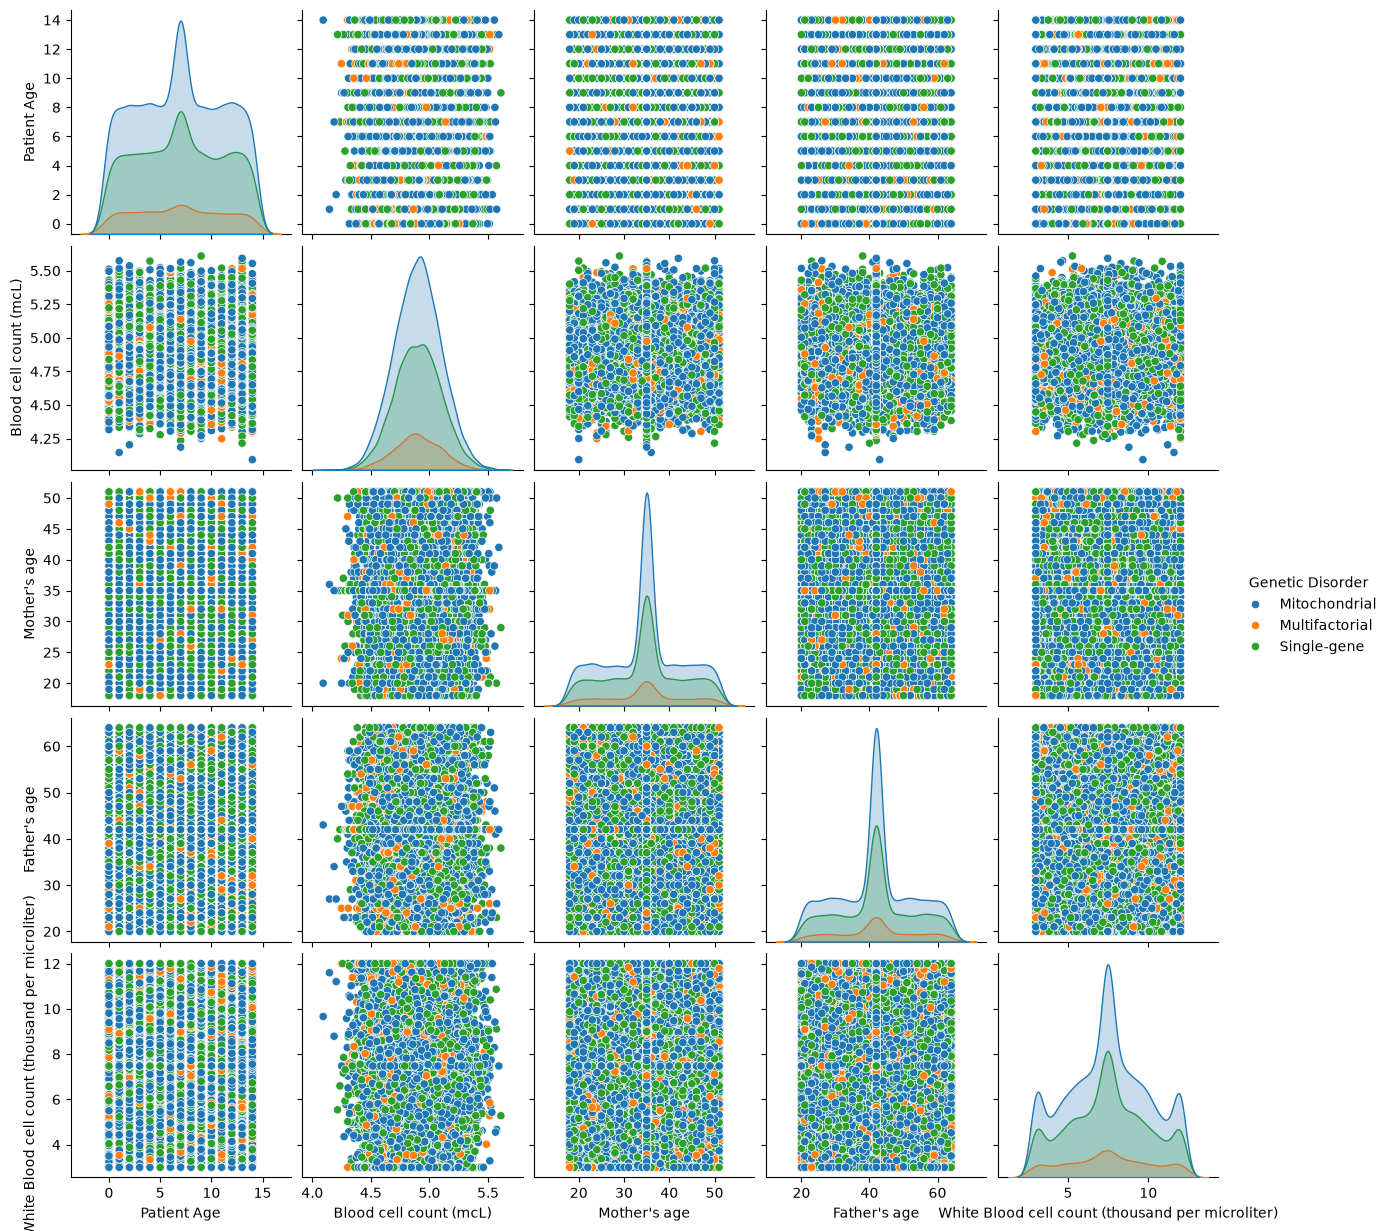

In [39]:
selected_cols = [
    "Patient Age",
    "Blood cell count (mcL)",
    "Mother's age",
    "Father's age",
    "White Blood cell count (thousand per microliter)",
    "Genetic Disorder"
]

sns.pairplot(train[selected_cols], hue="Genetic Disorder")
plt.show()